# Compression

In [1]:
!pip install torch torchvision opencv-python scikit-image matplotlib tqdm --quiet


In [2]:
# Create folders
!mkdir -p /content/DIV2K

# Download DIV2K HR images
!wget -q http://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_HR.zip -P /content/DIV2K
!wget -q http://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_valid_HR.zip -P /content/DIV2K

# Unzip
!unzip -q /content/DIV2K/DIV2K_train_HR.zip -d /content/DIV2K
!unzip -q /content/DIV2K/DIV2K_valid_HR.zip -d /content/DIV2K


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
import cv2, os, random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim


In [4]:
class DIV2KCompressionDataset(Dataset):
    def __init__(self, folder, patch_size=256):
        self.paths = [os.path.join(folder, f) for f in os.listdir(folder)]
        self.patch_size = patch_size
        self.to_tensor = T.ToTensor()

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        h, w, _ = img.shape
        x = random.randint(0, h - self.patch_size)
        y = random.randint(0, w - self.patch_size)

        patch = img[x:x+self.patch_size, y:y+self.patch_size]
        return self.to_tensor(patch)


In [5]:
class ImportanceNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 1, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


In [6]:
def compress(image, importance, base_q=40):
    """
    image      : [B,3,H,W]
    importance : [B,1,H,W]
    """
    Q = base_q * (1.5 - importance)
    Q = torch.clamp(Q, 10, 80)

    compressed = torch.round(image * 255 / Q) * Q / 255
    return torch.clamp(compressed, 0, 1)


In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = ImportanceNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.L1Loss()

train_loader = DataLoader(
    DIV2KCompressionDataset("/content/DIV2K/DIV2K_train_HR"),
    batch_size=8, shuffle=True, num_workers=2
)


In [8]:
def train(epochs=8):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for img in tqdm(train_loader):
            img = img.to(device)

            optimizer.zero_grad()
            importance = model(img)
            compressed = compress(img, importance)

            loss = criterion(compressed, img)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f}")

In [9]:
train(epochs=8)


100%|██████████| 100/100 [00:54<00:00,  1.85it/s]


Epoch 1 | Loss: 0.0389


100%|██████████| 100/100 [00:54<00:00,  1.84it/s]


Epoch 2 | Loss: 0.0370


100%|██████████| 100/100 [00:53<00:00,  1.86it/s]


...

Epoch 6 | Loss: 0.0212


100%|██████████| 100/100 [00:52<00:00,  1.90it/s]


Epoch 7 | Loss: 0.0204


100%|██████████| 100/100 [00:52<00:00,  1.89it/s]

Epoch 8 | Loss: 0.0199


In [10]:
val_dataset = DIV2KCompressionDataset("/content/DIV2K/DIV2K_valid_HR")
val_loader = DataLoader(val_dataset, batch_size=1)

def validate():
    model.eval()
    psnr_list, ssim_list = [], []

    with torch.no_grad():
        for img in val_loader:
            img = img.to(device)
            imp = model(img)
            comp = compress(img, imp)

            img_np = img[0].cpu().numpy().transpose(1,2,0)
            comp_np = comp[0].cpu().numpy().transpose(1,2,0)

            psnr_list.append(psnr(img_np, comp_np))
            ssim_list.append(ssim(img_np, comp_np, channel_axis=2))

    print("Avg PSNR:", np.mean(psnr_list))
    print("Avg SSIM:", np.mean(ssim_list))
    validate()

In [11]:
# Load one full-resolution 2K image
test_path = "/content/DIV2K/DIV2K_valid_HR/0801.png"
img = cv2.imread(test_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_tensor = T.ToTensor()(img).unsqueeze(0).to(device)

with torch.no_grad():
    importance = model(img_tensor)
    compressed = compress(img_tensor, importance)


In [12]:
orig_path = "/content/original_2k.png"
comp_path = "/content/compressed_2k.png"

orig_img = (img_tensor[0].cpu().numpy().transpose(1,2,0)*255).astype(np.uint8)
comp_img = (compressed[0].cpu().numpy().transpose(1,2,0)*255).astype(np.uint8)

cv2.imwrite(orig_path, cv2.cvtColor(orig_img, cv2.COLOR_RGB2BGR))
cv2.imwrite(comp_path, cv2.cvtColor(comp_img, cv2.COLOR_RGB2BGR))

orig_size = os.path.getsize(orig_path)/1024
comp_size = os.path.getsize(comp_path)/1024

print(f"Original size   : {orig_size:.2f} KB")
print(f"Compressed size : {comp_size:.2f} KB")
print(f"Compression %   : {(1-comp_size/orig_size)*100:.2f}%")


Original size   : 5166.02 KB
Compressed size : 2008.37 KB
Compression %   : 61.12%


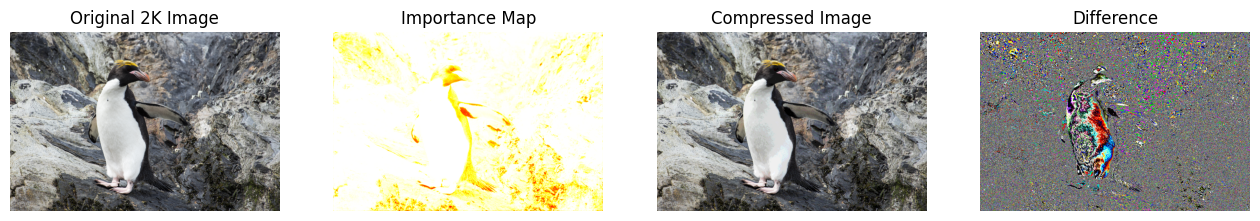

In [13]:
plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.title("Original 2K Image")
plt.imshow(orig_img)
plt.axis("off")

plt.subplot(1,4,2)
plt.title("Importance Map")
plt.imshow(importance[0,0].cpu(), cmap="hot")
plt.axis("off")

plt.subplot(1,4,3)
plt.title("Compressed Image")
plt.imshow(comp_img)
plt.axis("off")

plt.subplot(1,4,4)
plt.title("Difference")
plt.imshow(np.abs(orig_img - comp_img))
plt.axis("off")

plt.show()


In [14]:
def evaluate_model_accuracy(model, dataloader, device):
    model.eval()

    psnr_list = []
    ssim_list = []

    with torch.no_grad():
        for img in dataloader:
            img = img.to(device)

            importance = model(img)
            compressed = compress(img, importance)

            orig = img[0].cpu().numpy().transpose(1,2,0)
            comp = compressed[0].cpu().numpy().transpose(1,2,0)

            psnr_val = psnr(orig, comp)
            ssim_val = ssim(orig, comp, channel_axis=2, data_range=1.0)

            psnr_list.append(psnr_val)
            ssim_list.append(ssim_val)

    avg_psnr = np.mean(psnr_list)
    avg_ssim = np.mean(ssim_list)

    print("===== MODEL ACCURACY (COMPRESSION) =====")
    print(f"PSNR Accuracy : {avg_psnr:.2f} dB")
    print(f"SSIM Accuracy : {avg_ssim:.4f}")
    print("========================================")

    return avg_psnr, avg_ssim

psnr_acc, ssim_acc = evaluate_model_accuracy(model, val_loader, device)

===== MODEL ACCURACY (COMPRESSION) =====
PSNR Accuracy : 32.67 dB
SSIM Accuracy : 0.8788


# Reconstruction

In [15]:
def get_difference_map(original, compressed):
    return original - compressed


In [16]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1)
        )

    def forward(self, x):
        return x + 0.1 * self.block(x)


In [17]:
class ReconstructionNet(nn.Module):
    def __init__(self, num_blocks=8):
        super().__init__()

        # Input: compressed(3) + importance(1) + difference(3) = 7 channels
        self.head = nn.Conv2d(7, 64, 3, padding=1)

        self.body = nn.Sequential(
            *[ResidualBlock(64) for _ in range(num_blocks)]
        )

        self.tail = nn.Conv2d(64, 3, 3, padding=1)

    def forward(self, compressed, importance, diff):
        x = torch.cat([compressed, importance, diff], dim=1)
        x = self.head(x)
        res = self.body(x)
        x = x + res
        return self.tail(x)


In [18]:
def edge_loss(pred, target):
    sobel_x = torch.tensor([[1,0,-1],[2,0,-2],[1,0,-1]],
                           dtype=torch.float32, device=pred.device).view(1,1,3,3)
    sobel_y = sobel_x.transpose(2,3)

    pred_gray = pred.mean(1, keepdim=True)
    target_gray = target.mean(1, keepdim=True)

    pred_edges = (
        torch.nn.functional.conv2d(pred_gray, sobel_x, padding=1) +
        torch.nn.functional.conv2d(pred_gray, sobel_y, padding=1)
    )
    target_edges = (
        torch.nn.functional.conv2d(target_gray, sobel_x, padding=1) +
        torch.nn.functional.conv2d(target_gray, sobel_y, padding=1)
    )

    return torch.nn.functional.l1_loss(pred_edges, target_edges)


In [19]:
recon_model = ReconstructionNet().to(device)
optimizer_r = optim.Adam(recon_model.parameters(), lr=1e-4)
criterion_r = nn.L1Loss()


In [20]:
for p in model.parameters():
    p.requires_grad = False


In [21]:
def train_reconstruction(epochs=10):
    recon_model.train()
    for epoch in range(epochs):
        total_loss = 0

        for img in tqdm(train_loader):
            img = img.to(device)

            with torch.no_grad():
                importance = model(img)
                compressed = compress(img, importance)
                diff = get_difference_map(img, compressed)

            reconstructed = recon_model(compressed, importance, diff)

            loss = (
                criterion_r(reconstructed, img)
                + 0.1 * edge_loss(reconstructed, img)
            )

            optimizer_r.zero_grad()
            loss.backward()
            optimizer_r.step()

            total_loss += loss.item()

        print(f"Reconstruction Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f}")


In [22]:
train_reconstruction(epochs=10)


100%|██████████| 100/100 [01:08<00:00,  1.47it/s]


Reconstruction Epoch 1 | Loss: 0.1108


100%|██████████| 100/100 [01:07<00:00,  1.49it/s]


Reconstruction Epoch 2 | Loss: 0.0400


100%|██████████| 100/100 [01:07<00:00,  1.48it/s]


...

Reconstruction Epoch 8 | Loss: 0.0106


100%|██████████| 100/100 [01:08<00:00,  1.46it/s]


Reconstruction Epoch 9 | Loss: 0.0107


100%|██████████| 100/100 [01:08<00:00,  1.46it/s]

Reconstruction Epoch 10 | Loss: 0.0099


In [23]:
def evaluate_reconstruction(model_c, model_r, dataloader):
    model_c.eval()
    model_r.eval()

    psnr_list, ssim_list = [], []

    with torch.no_grad():
        for img in dataloader:
            img = img.to(device)

            imp = model_c(img)
            comp = compress(img, imp)
            diff = get_difference_map(img, comp)

            rec = model_r(comp, imp, diff)

            orig = img[0].cpu().numpy().transpose(1,2,0)
            recon = rec[0].cpu().numpy().transpose(1,2,0)

            psnr_list.append(psnr(orig, recon))
            ssim_list.append(ssim(orig, recon, channel_axis=2, data_range=1.0))

    print("===== RECONSTRUCTION ACCURACY =====")
    print(f"PSNR : {np.mean(psnr_list):.2f} dB")
    print(f"SSIM : {np.mean(ssim_list):.4f}")


In [24]:
evaluate_reconstruction(model, recon_model, val_loader)


===== RECONSTRUCTION ACCURACY =====
PSNR : 36.43 dB
SSIM : 0.9769


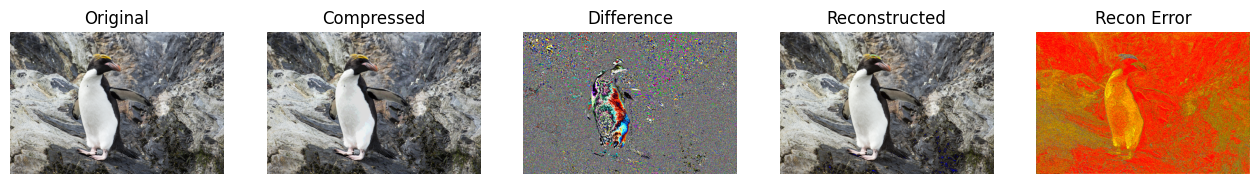

In [25]:
with torch.no_grad():
    imp = model(img_tensor)
    comp = compress(img_tensor, imp)
    diff = get_difference_map(img_tensor, comp)
    recon = recon_model(comp, imp, diff)

recon_img = (recon[0].cpu().numpy().transpose(1,2,0)*255).astype(np.uint8)

plt.figure(figsize=(16,4))
plt.subplot(1,5,1); plt.title("Original"); plt.imshow(orig_img); plt.axis("off")
plt.subplot(1,5,2); plt.title("Compressed"); plt.imshow(comp_img); plt.axis("off")
plt.subplot(1,5,3); plt.title("Difference"); plt.imshow(np.abs(orig_img-comp_img)); plt.axis("off")
plt.subplot(1,5,4); plt.title("Reconstructed"); plt.imshow(recon_img); plt.axis("off")
plt.subplot(1,5,5); plt.title("Recon Error"); plt.imshow(np.abs(orig_img-recon_img)); plt.axis("off")
plt.show()


## Test


In [26]:
import random
import os

# Dataset path
dataset_path = "/content/DIV2K/DIV2K_valid_HR"

# Get 3 random images
test_images = random.sample(os.listdir(dataset_path), 3)

print("Selected Test Images:")
for img in test_images:
    print(img)

Selected Test Images:
0840.png
0896.png
0808.png


In [30]:
import torchvision.transforms as T
import cv2
import numpy as np

def test_model(image_path):

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    original = img.copy()

    img_tensor = T.ToTensor()(img).unsqueeze(0).to(device)

    with torch.no_grad():

        importance = model(img_tensor)
        compressed_tensor = compress(img_tensor, importance)
        diff = get_difference_map(img_tensor, compressed_tensor)
        reconstructed_tensor = recon_model(compressed_tensor, importance, diff)

    comp_img = (compressed_tensor[0].cpu().permute(1,2,0).numpy()*255).astype(np.uint8)
    recon_img = (reconstructed_tensor[0].cpu().permute(1,2,0).numpy()*255).astype(np.uint8)

    return original, comp_img, recon_img

In [28]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def calculate_metrics(original, recon):

    psnr_val = psnr(original, recon)
    ssim_val = ssim(original, recon, channel_axis=2)

    similarity = ssim_val * 100

    return psnr_val, ssim_val, similarity

Image: 0840.png
PSNR : 18.62 dB
SSIM : 0.9569
Similarity : 95.69 %


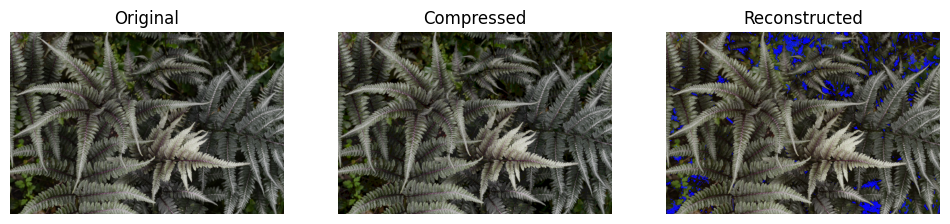

Image: 0896.png
PSNR : 33.82 dB
SSIM : 0.9875
Similarity : 98.75 %


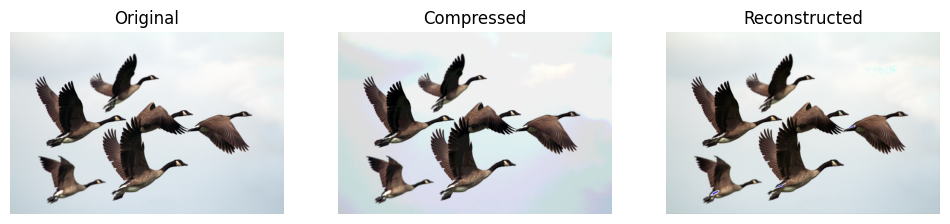

Image: 0808.png
PSNR : 20.71 dB
SSIM : 0.9384
Similarity : 93.84 %


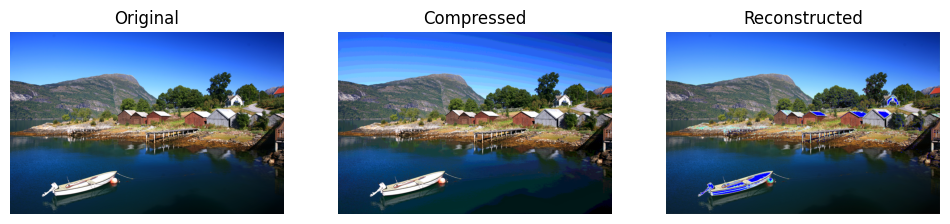

In [32]:
for img_name in test_images:

    image_path = os.path.join(dataset_path, img_name)

    original, comp, recon = test_model(image_path)

    psnr_val, ssim_val, similarity = calculate_metrics(original, recon)

    print("====================================")
    print("Image:", img_name)
    print(f"PSNR : {psnr_val:.2f} dB")
    print(f"SSIM : {ssim_val:.4f}")
    print(f"Similarity : {similarity:.2f} %")
    print("====================================")

    # Show images
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(original)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Compressed")
    plt.imshow(comp)
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Reconstructed")
    plt.imshow(recon)
    plt.axis("off")

    plt.show()

## Space images


In [40]:
test_images = [
"/content/history-in-hd-e5eDHbmHprg-unsplash.jpg",
"/content/nasa-U2uKrI4lci8-unsplash.jpg",
"/content/nasa-rTZW4f02zY8-unsplash.jpg",
"/content/nasa-yZygONrUBe8-unsplash.jpg",
"/content/original_2k.png",
"/content/shot-by-cerqueira-Oo_GEzyargo-unsplash.jpg"
]

In [47]:
import torchvision.transforms as T
import cv2
import numpy as np
import os

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def test_external_image(image_path):

    img = cv2.imread(image_path)
    if img is None:
        print(f"Warning: Could not read image at {image_path}. Skipping.")
        return None, None, None # Return None for all outputs to indicate failure

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    original = img.copy()

    h, w, _ = img.shape
    patch_size = 128 # Reduced patch size to mitigate OOM for ReconstructionNet

    # Check if image is larger than patch_size in any dimension
    if h > patch_size or w > patch_size:
        reconstructed_full = np.zeros_like(original, dtype=np.float32)
        compressed_full = np.zeros_like(original, dtype=np.float32)

        for i in range(0, h, patch_size):
            for j in range(0, w, patch_size):
                h_start = i
                h_end = min(i + patch_size, h)
                w_start = j
                w_end = min(j + patch_size, w)

                patch = img[h_start:h_end, w_start:w_end]

                # Pad patch if it's smaller than patch_size (at edges)
                # This ensures consistent input size for the model
                padded_patch = np.zeros((patch_size, patch_size, 3), dtype=np.uint8)
                padded_patch[:patch.shape[0], :patch.shape[1], :] = patch

                patch_tensor = T.ToTensor()(padded_patch).unsqueeze(0).to(device)

                with torch.no_grad():
                    importance_patch = model(patch_tensor)
                    compressed_patch_tensor = compress(patch_tensor, importance_patch)
                    diff_patch = get_difference_map(patch_tensor, compressed_patch_tensor)
                    reconstructed_patch_tensor = recon_model(compressed_patch_tensor, importance_patch, diff_patch)

                # Convert reconstructed patch back to numpy (0-1 range)
                reconstructed_patch_np = reconstructed_patch_tensor[0].cpu().permute(1,2,0).numpy()
                compressed_patch_np = compressed_patch_tensor[0].cpu().permute(1,2,0).numpy()

                # Place reconstructed patch back into the full image canvas
                reconstructed_full[h_start:h_end, w_start:w_end, :] = reconstructed_patch_np[:(h_end-h_start), :(w_end-w_start), :]
                compressed_full[h_start:h_end, w_start:w_end, :] = compressed_patch_np[:(h_end-h_start), :(w_end-w_start), :]

        recon_img = (reconstructed_full * 255).astype(np.uint8)
        comp_img = (compressed_full * 255).astype(np.uint8)

    else:
        # Process full image if it's small enough
        img_tensor = T.ToTensor()(img).unsqueeze(0).to(device)

        with torch.no_grad():
            importance = model(img_tensor)
            compressed_tensor = compress(img_tensor, importance)
            diff = get_difference_map(img_tensor, compressed_tensor)
            reconstructed_tensor = recon_model(compressed_tensor, importance, diff)

        comp_img = (compressed_tensor[0].cpu().permute(1,2,0).numpy()*255).astype(np.uint8)
        recon_img = (reconstructed_tensor[0].cpu().permute(1,2,0).numpy()*255).astype(np.uint8)

    return original, comp_img, recon_img


Testing Image: history-in-hd-e5eDHbmHprg-unsplash.jpg
PSNR : 8.27 dB
SSIM : 0.7083
Similarity : 70.83 %
Compression : 55.78 %


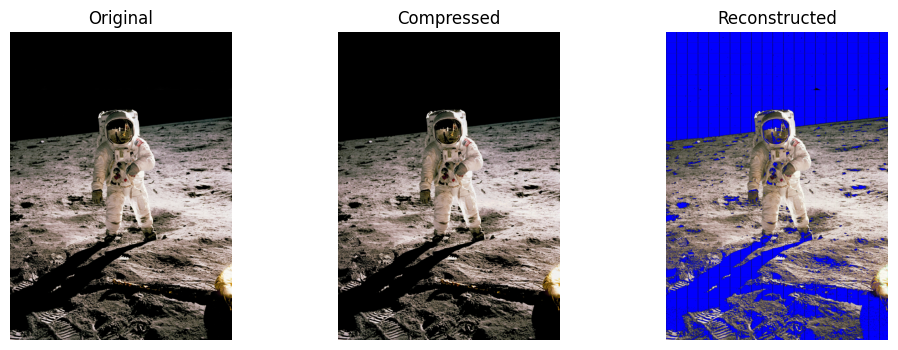


Testing Image: nasa-U2uKrI4lci8-unsplash.jpg
PSNR : 24.35 dB
SSIM : 0.9229
Similarity : 92.29 %
Compression : 57.26 %


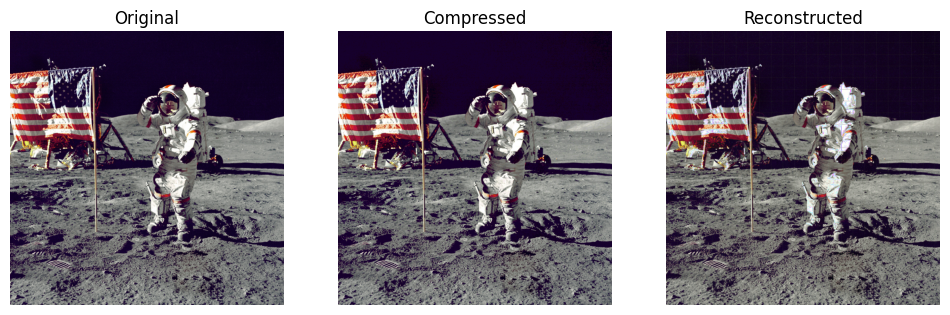


Testing Image: nasa-rTZW4f02zY8-unsplash.jpg
PSNR : 33.56 dB
SSIM : 0.9405
Similarity : 94.05 %
Compression : 56.26 %


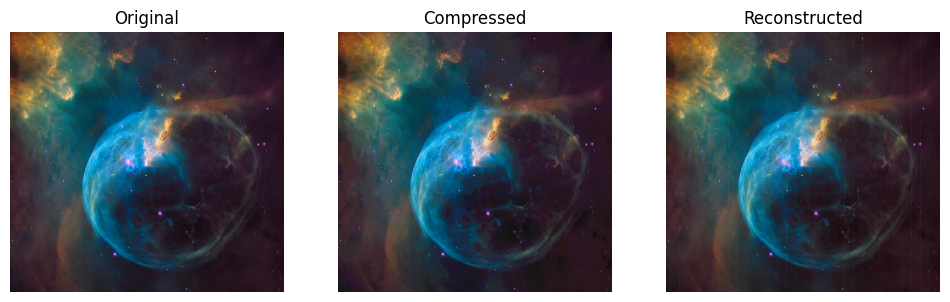


Testing Image: nasa-yZygONrUBe8-unsplash.jpg
PSNR : 23.36 dB
SSIM : 0.9439
Similarity : 94.39 %
Compression : 62.20 %


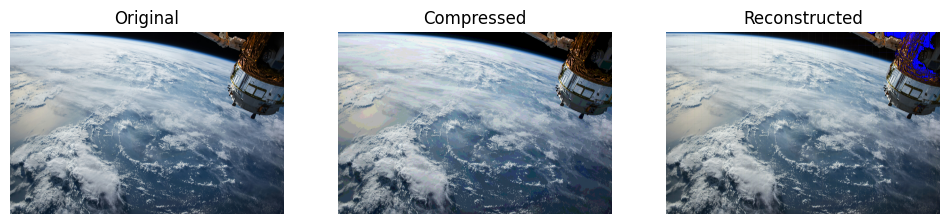


Testing Image: original_2k.png
PSNR : 30.56 dB
SSIM : 0.9738
Similarity : 97.38 %
Compression : 57.87 %


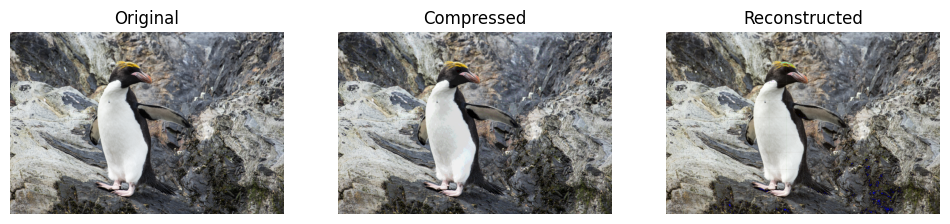


Testing Image: shot-by-cerqueira-Oo_GEzyargo-unsplash.jpg
Skipping processing for shot-by-cerqueira-Oo_GEzyargo-unsplash.jpg due to read error.


In [48]:
for image_path in test_images:

    print("\n====================================")
    print("Testing Image:", os.path.basename(image_path))

    original, comp, recon = test_external_image(image_path)

    if original is None: # Check if image reading failed
        print(f"Skipping processing for {os.path.basename(image_path)} due to read error.")
        print("====================================")
        continue # Skip to the next image

    # Metrics
    psnr_val = psnr(original, recon)
    ssim_val = ssim(original, recon, channel_axis=2)

    similarity = ssim_val * 100

    # Save temporary images to compute compression %
    cv2.imwrite("/content/temp_original.png", cv2.cvtColor(original, cv2.COLOR_RGB2BGR))
    cv2.imwrite("/content/temp_compressed.png", cv2.cvtColor(comp, cv2.COLOR_RGB2BGR))

    orig_size = os.path.getsize("/content/temp_original.png") / 1024
    comp_size = os.path.getsize("/content/temp_compressed.png") / 1024

    compression_percent = (1 - comp_size/orig_size) * 100

    print(f"PSNR : {psnr_val:.2f} dB")
    print(f"SSIM : {ssim_val:.4f}")
    print(f"Similarity : {similarity:.2f} %")
    print(f"Compression : {compression_percent:.2f} %")

    print("====================================")

    # Display images
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(original)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Compressed")
    plt.imshow(comp)
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Reconstructed")
    plt.imshow(recon)
    plt.axis("off")

    plt.show()